<a href="https://colab.research.google.com/github/jaiswalakanksha22-glitch/Python-AI/blob/AI/Project5_Jaiswal_Akanksha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You are a data scientist in an e-commerce company. You are given a Women’s Clothing E-Commerce dataset revolving around the reviews written by customers. This dataset contains the following columns:

Clothing ID
Age
Title
Review Text
Rating
Recommended IND
Positive Feedback Count
Division Name
Department Name
Class Name

**Steps and Questions**:
Load the data, Women's Clothing E-Commerce Reviews.csv Download Women's Clothing E-Commerce Reviews.csv, into memory.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Womens Clothing E-Commerce Reviews.csv to Womens Clothing E-Commerce Reviews.csv


In [18]:
import pandas as pd

df = pd.read_csv("Womens Clothing E-Commerce Reviews.csv")
df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


Please concatenate the Title, Review Text, Division Name, Department Name, and Class Name as a new feature of Reviews.

In [19]:
# Fill missing values with empty strings to avoid errors
cols = ["Title", "Review Text", "Division Name", "Department Name", "Class Name"]
df[cols] = df[cols].fillna("")

# Concatenate into a new column
df["Reviews"] = df["Title"] + " " + df["Review Text"] + " " + \
                df["Division Name"] + " " + df["Department Name"] + " " + \
                df["Class Name"]

# Preview
df[["Reviews"]].head()

,Reviews
0,Absolutely wonderful - silky and sexy and com...
1,Love this dress! it's sooo pretty. i happen...
2,Some major design flaws I had such high hopes ...
3,"My favorite buy! I love, love, love this jumps..."
4,Flattering shirt This shirt is very flattering...


In [20]:
df.shape        # number of rows and columns
df.columns      # list of columns
df.info()       # data types and null values
df.describe()   # summary statistics

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    23486 non-null  object
 4   Review Text              23486 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23486 non-null  object
 9   Department Name          23486 non-null  object
 10  Class Name               23486 non-null  object
 11  Reviews                  23486 non-null  object
dtypes: int64(6), object(6)
memory usage: 2.2+ MB


,Unnamed: 0,Clothing ID,Age,Rating,Recommended IND,Positive Feedback Count
count,23486.000000,23486.000000,23486.000000,23486.000000,23486.000000,23486.000000
mean,11742.500000,918.118709,43.198544,4.196032,0.822362,2.535936
std,6779.968547,203.298980,12.279544,1.110031,0.382216,5.702202
min,0.000000,0.000000,18.000000,1.000000,0.000000,0.000000
25%,5871.250000,861.000000,34.000000,4.000000,1.000000,0.000000
50%,11742.500000,936.000000,41.000000,5.000000,1.000000,1.000000
75%,17613.750000,1078.000000,52.000000,5.000000,1.000000,3.000000
max,23485.000000,1205.000000,99.000000,5.000000,1.000000,122.000000


Please clean the new feature of Reviews using regular expressions.

In [21]:
import re

def clean_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags (if any)
    text = re.sub(r"<.*?>", " ", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove numbers
    text = re.sub(r"\d+", " ", text)

    # Remove punctuation and special characters
    text = re.sub(r"[^\w\s]", " ", text)

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

# Apply cleaning function
df["Reviews_clean"] = df["Reviews"].apply(clean_text)

# Preview
df[["Reviews", "Reviews_clean"]].head()

,Reviews,Reviews_clean
0,Absolutely wonderful - silky and sexy and com...,absolutely wonderful silky and sexy and comfor...
1,Love this dress! it's sooo pretty. i happen...,love this dress it s sooo pretty i happened to...
2,Some major design flaws I had such high hopes ...,some major design flaws i had such high hopes ...
3,"My favorite buy! I love, love, love this jumps...",my favorite buy i love love love this jumpsuit...
4,Flattering shirt This shirt is very flattering...,flattering shirt this shirt is very flattering...


Build an RNN model to forecast the Recommended IND based on Reviews using TensorFlow.

1. Prepare the data

In [22]:
import numpy as np

# Features and target
X = df["Reviews_clean"]
y = df["Recommended IND"]

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

2. Tokenization & Padding

In [23]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Hyperparameters
vocab_size = 10000
max_len = 100

# Tokenizer
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Padding
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

3. Build the RNN Model

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=64, input_length=max_len),

    SimpleRNN(64, return_sequences=False),

    Dropout(0.5),

    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')   # Binary classification
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

4. Train the Model

In [25]:
history = model.fit(
    X_train_pad, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
470/470 ━━━━━━━━━━━━━━━━━━━━ 17s 31ms/step - accuracy: 0.8214 - loss: 0.4782 - val_accuracy: 0.8199 - val_loss: 0.4748
Epoch 2/5
470/470 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - accuracy: 0.8239 - loss: 0.4759 - val_accuracy: 0.8199 - val_loss: 0.4838
Epoch 3/5
470/470 ━━━━━━━━━━━━━━━━━━━━ 21s 32ms/step - accuracy: 0.8241 - loss: 0.4742 - val_accuracy: 0.8199 - val_loss: 0.4867
Epoch 4/5
470/470 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.8241 - loss: 0.4703 - val_accuracy: 0.8199 - val_loss: 0.4773
Epoch 5/5
470/470 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.8241 - loss: 0.4699 - val_accuracy: 0.8199 - val_loss: 0.4771


 5. Evaluate the Model

In [26]:
loss, accuracy = model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", accuracy)

147/147 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8189 - loss: 0.4781
Test Accuracy: 0.8188591003417969


Evaluate on test Data

In [27]:
y_pred_prob = model.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int)

147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


Classification metrics

In [28]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       851
           1       0.82      1.00      0.90      3847

    accuracy                           0.82      4698
   macro avg       0.41      0.50      0.45      4698
weighted avg       0.67      0.82      0.74      4698

[[   0  851]
 [   0 3847]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Check Model Fit (Overfitting / Underfitting)

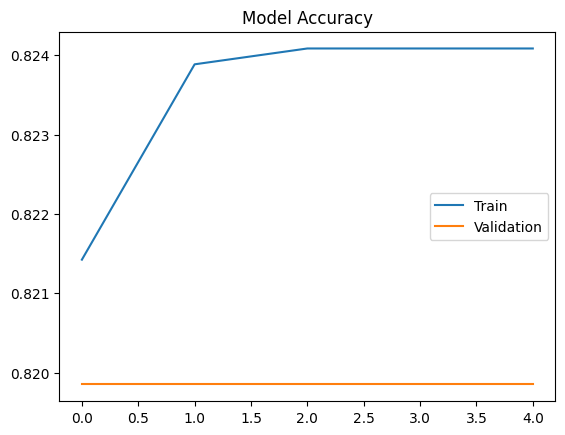

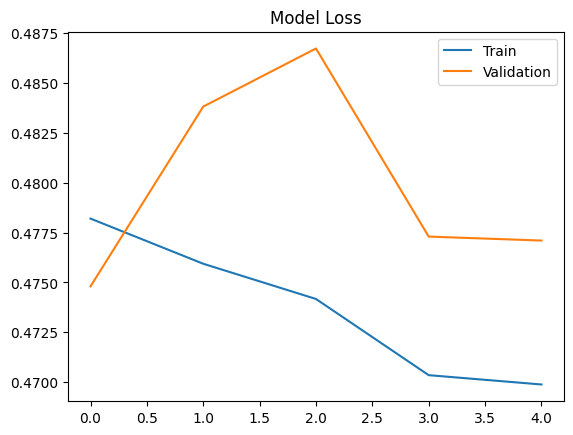

In [29]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss plot
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.legend(['Train', 'Validation'])
plt.show()

Final Conclusion
Model is well-trained but poorly designed
Accuracy is misleading due to imbalance
Model is not usable in real-world.
Model is NOT recommended.
The RNN model achieved an accuracy of approximately 81.9%, which initially appears acceptable. However, further evaluation using the confusion matrix and classification report reveals that the model predicts only the majority class (Recommended = 1) for all samples.